In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

brill1819_llm_finetuning_path = kagglehub.dataset_download('brill1819/llm-finetuning')
brill1819_llm_finetuning2_path = kagglehub.dataset_download('brill1819/llm-finetuning2')

print('Data source import complete.')


Data source import complete.


# LLM Fine-Tuning — biomistral(QLoRA, Kaggle 2×T4 GPU)
### Lab Report Dashboard Project — Simplification/Generation Layer

## 1. Environment Check — Confirm Both GPUs Are Visible

In [3]:
!nvidia-smi --query-gpu=index,name,memory.total,memory.used --format=csv
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")


index, name, memory.total [MiB], memory.used [MiB]
0, Tesla T4, 15360 MiB, 0 MiB
CUDA available: True
GPU count: 1
  GPU 0: Tesla T4


## 2. Install Dependencies

In [4]:
!pip install -q -U transformers accelerate peft bitsandbytes trl datasets huggingface_hub

## 3. Authenticate with Hugging Face



In [5]:
from huggingface_hub import login

try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    from getpass import getpass
    hf_token = getpass("Enter your Hugging Face token: ")

login(token=hf_token)

Enter your Hugging Face token: ··········


## 4. Loading the Dataset

In [6]:
import pandas as pd
import json
import os

# Load generated instruction dataset
csv_path=os.path.join(brill1819_llm_finetuning2_path, 'llm_annotated_lab_results (14).csv')
df=pd.read_csv(csv_path)

In [7]:
df.head()

,report_id,source,lab_results_json,summary_text,total_tests,abnormal_count,llm_model,llm_prompt,llm_response,llm_error,timestamp
0,MIMIC_III_10006_0,MIMIC-III,"[{""test"": ""Lymphocytes"", ""value"": 2.9, ""unit"":...",Found 2 lab tests.,2,2,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,"- **Lymphocytes (2.9, low):** Lymphocytes are ...",NaN,2026-08-04T18:33:09.311659+00:00
1,MIMIC_III_10006_10,MIMIC-III,"[{""test"": ""Creatinine"", ""value"": 5.7, ""unit"": ...",Found 4 lab tests.,4,1,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,"- **Creatinine (5.7, high):** Creatinine is a ...",NaN,2026-08-04T18:33:14.330888+00:00
2,MIMIC_III_10006_12,MIMIC-III,"[{""test"": ""Chloride"", ""value"": 99.0, ""unit"": ""...",Found 2 lab tests.,2,0,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,- **Chloride (99.0):** Chloride helps keep the...,NaN,2026-08-04T18:33:19.292325+00:00
3,MIMIC_III_10006_14,MIMIC-III,"[{""test"": ""Sodium"", ""value"": 40.0, ""unit"": ""mg...",Found 3 lab tests.,3,1,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,"- **Sodium (40.0, low):** Sodium helps control...",NaN,2026-08-04T18:33:24.096299+00:00
4,MIMIC_III_10006_16,MIMIC-III,"[{""test"": ""Sodium"", ""value"": 136.0, ""unit"": ""m...",Found 4 lab tests.,4,0,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,- **Sodium (136):** Sodium helps regulate flui...,NaN,2026-08-04T18:33:29.115603+00:00


In [8]:
df["llm_response"][0]

'- **Lymphocytes (2.9, low):** Lymphocytes are a type of white‑blood cell that help fight infections. A low count can mean the immune system is a bit weakened, which sometimes follows a recent illness, certain medications, or other medical conditions.  \n- **Glucose (179, high):** Glucose measures the amount of sugar in your blood. A level this high suggests elevated blood sugar, which may be an early sign of pre‑diabetes or diabetes and can increase the risk of long‑term complications if not addressed.\n\n**Recommendation:** Talk with your doctor about both results. They may want to repeat the tests, look for any recent infections, review any medicines you’re taking, and assess your risk for diabetes. Lifestyle steps such as balanced meals, regular physical activity, and weight management can help lower blood sugar, while staying up‑to‑date on vaccinations and avoiding unnecessary stress can support your immune system. Your provider can guide any further testing or treatment needed.'

In [76]:
df.shape

(507, 11)

## 5. Splitting the Dataset

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['llm_model'])

In [10]:
train_df.head()

,report_id,source,lab_results_json,summary_text,total_tests,abnormal_count,llm_model,llm_prompt,llm_response,llm_error,timestamp
186,MIMIC_III_10026_39,MIMIC-III,"[{""test"": ""Creatinine"", ""value"": 0.5, ""unit"": ...",Found 1 lab tests.,1,1,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,"- **Creatinine (0.5, low):** Creatinine is a w...",NaN,2026-08-04T18:48:25.442922+00:00
221,MIMIC_III_10027_30,MIMIC-III,"[{""test"": ""Glucose"", ""value"": 223.0, ""unit"": ""...",Found 7 lab tests.,7,1,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,"- **Glucose (223, high):** Blood sugar provide...",NaN,2026-08-04T18:51:19.891452+00:00
467,MIMIC_III_10040_3,MIMIC-III,"[{""test"": ""Platelet"", ""value"": 196.0, ""unit"": ...",Found 3 lab tests.,3,0,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,"- **Platelets (196 K/uL, normal):** Platelets ...",NaN,2026-08-04T19:18:18.438833+00:00
398,MIMIC_III_10036_4,MIMIC-III,"[{""test"": ""Platelet"", ""value"": 206.0, ""unit"": ...",Found 3 lab tests.,3,1,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,- **Platelets (206.0):** Platelets help your b...,NaN,2026-08-04T19:12:33.823476+00:00
73,MIMIC_III_10013_1,MIMIC-III,"[{""test"": ""Bicarbonate"", ""value"": 29.0, ""unit""...",Found 4 lab tests.,4,1,openai/gpt-oss-120b,Analyze these lab results and provide patient-...,- **Bicarbonate (29.0):** Helps keep your bloo...,NaN,2026-08-04T18:39:08.282439+00:00


In [11]:
# Expected columns: prompt,response OR instruction,response
prompt_col='lab_results_json' if 'lab_results_json' in df.columns else ('instruction' if 'instruction' in df.columns else df.columns[0])
response_col='llm_response' if 'llm_response' in df.columns else df.columns[1]

chat_examples=[{
    'messages':[
        {'role':'user','content':str(r[prompt_col])},
        {'role':'assistant','content':str(r[response_col])}
    ]
} for _,r in train_df.iterrows()]

print(f'Loaded {len(chat_examples)} examples')

Loaded 405 examples


## 6. Build the Hugging Face Dataset (Train/Validation Split)

In [12]:
from datasets import Dataset

hf_dataset = Dataset.from_list(chat_examples)
split = hf_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]
eval_dataset = split["test"]

print(f"Train examples: {len(train_dataset)} | Eval examples: {len(eval_dataset)}")


Train examples: 324 | Eval examples: 81


In [13]:
train_dataset['messages']

Column([[{'role': 'user', 'content': '[{"test": "Hemoglobin", "value": 11.9, "unit": "g/dL", "test_name": "Hemoglobin", "status": "LOW"}, {"test": "Chloride", "value": 9.5, "unit": "mg/dL", "test_name": "Chloride", "status": "LOW"}]'}, {'role': 'assistant', 'content': '- **Hemoglobin (11.9, low):** Carries oxygen in your red blood cells; a low level  \n  can indicate mild anemia, which may cause fatigue or shortness of breath.  \n\n- **Chloride (9.5, low):** An important electrolyte that helps balance fluids and maintain acid‑base balance; low chloride can be a sign of dehydration, certain kidney issues, or an acid‑base disturbance.  \n\n**Recommendation:** Discuss both the low hemoglobin and low chloride with your  \ndoctor — they may order additional tests to pinpoint the cause and suggest  \ntreatment such as dietary changes, supplements, or other therapy.'}], [{'role': 'user', 'content': '[{"test": "Hemoglobin", "value": 76.5, "unit": "sec", "test_name": "Hemoglobin", "status": "HI

## 7. Load the Base Model with QLoRA (4-bit) — Both GPUs Visible

With 2 GPUs visible and `device_map="auto"`, `transformers` will shard the model across both
GPUs automatically if needed, and `Trainer` will use `DataParallel` across both during training
since this notebook runs as a single process.


In [14]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [17]:
MODEL_ID = "BioMistral/BioMistral-7B"  # swap this to try a different base model

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
tokenizer.pad_token_id=tokenizer.eos_token_id
model.config.use_cache = False  # required for gradient checkpointing during training
print("Model loaded across devices:", model.hf_device_map if hasattr(model, "hf_device_map") else "single device")

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  493kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Error during conversion: ReadTimeout('The read operation timed out')


generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Model loaded across devices: single device


## 8. Hyperparameter Search for the LoRA Config with Optuna

Instead of picking `r`, `lora_alpha`, `lora_dropout`, and `learning_rate` by hand, this section
uses [Optuna](https://optuna.org/) to search for a good combination automatically.

How it works:
- Each **trial** proposes a LoRA config + learning rate, attaches a fresh LoRA adapter to the
  already-loaded 4-bit base model (`model.unload()` strips the adapter from the previous trial
  so the underlying quantized weights are reused — no reloading from disk needed).
- The trial trains for a small number of steps (`SEARCH_MAX_STEPS`) on a subset of the training
  data, then evaluates on a subset of the validation data.
- The **objective** is the resulting eval loss (lower is better).
- Optuna's TPE sampler uses the results of previous trials to pick more promising configs for
  the next one, with a `MedianPruner` to stop clearly-bad trials early.
- After the search, the best config is rebuilt as `lora_config` and applied to `model` so the
  full training run in the next sections uses the tuned hyperparameters.

This adds runtime (roughly `N_TRIALS × SEARCH_MAX_STEPS` extra forward/backward passes), so keep
`N_TRIALS` and `SEARCH_MAX_STEPS` modest on Kaggle's session time limit. Skip this section
entirely if you just want to use the default `lora_config` from section 8.

In [ ]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

model = prepare_model_for_kbit_training(model)

# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
#     target_modules=[
#         "q_proj", "k_proj", "v_proj", "o_proj",
#         "gate_proj", "up_proj", "down_proj",
#     ],
# )

# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()


In [ ]:
# !pip install -q -U optuna

In [ ]:
# import copy
# import gc

# import optuna
# import torch
# from peft import LoraConfig, get_peft_model
# from trl import SFTConfig, SFTTrainer

# # Strip the default adapter created in section 8 so each trial starts from the
# # plain 4-bit base model (already prepared via `prepare_model_for_kbit_training`).
# # model = model.unload()

# # --- Search budget (tune these to fit your Kaggle time limit) ---
# N_TRIALS = 8
# SEARCH_MAX_STEPS = 30          # short training run per trial, not a full epoch
# SEARCH_TRAIN_SUBSET = 200      # number of training examples used per trial
# SEARCH_EVAL_SUBSET = 60        # number of eval examples used per trial

# search_train_dataset = train_dataset.select(range(min(SEARCH_TRAIN_SUBSET, len(train_dataset))))
# search_eval_dataset = eval_dataset.select(range(min(SEARCH_EVAL_SUBSET, len(eval_dataset))))

FIXED_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]


# def objective(trial: optuna.Trial) -> float:
#     r = trial.suggest_categorical("r", [8, 16, 32, 64])
#     alpha_mult = trial.suggest_categorical("alpha_mult", [1, 2, 4])  # lora_alpha = r * alpha_mult
#     lora_dropout = trial.suggest_float("lora_dropout", 0.0, 0.2)
#     learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)

#     trial_lora_config = LoraConfig(
#         r=r,
#         lora_alpha=r * alpha_mult,
#         lora_dropout=lora_dropout,
#         bias="none",
#         task_type="CAUSAL_LM",
#         target_modules=FIXED_TARGET_MODULES,
#     )

#     trial_model = get_peft_model(model, trial_lora_config)

#     trial_args = SFTConfig(
#         output_dir=f"/kaggle/working/optuna-trial-{trial.number}",
#         max_steps=SEARCH_MAX_STEPS,
#         per_device_train_batch_size=2,
#         per_device_eval_batch_size=2,
#         gradient_accumulation_steps=4,
#         learning_rate=learning_rate,
#         lr_scheduler_type="cosine",
#         warmup_ratio=0.03,
#         logging_steps=50,
#         eval_strategy="no",
#         save_strategy="no",
#         bf16=True,
#         max_length=1024,
#         packing=False,
#         report_to="none",
#         disable_tqdm=True,
#         loss_type="nll"
#     )

#     trial_trainer = SFTTrainer(
#         model=trial_model,
#         args=trial_args,
#         train_dataset=search_train_dataset,
#         eval_dataset=search_eval_dataset,
#         processing_class=tokenizer,
#     )

#     trial_trainer.train()
#     eval_metrics = trial_trainer.evaluate()
#     eval_loss = eval_metrics["eval_loss"]

#     # Clean up so the next trial starts from the plain base model again.
#     del trial_trainer
#     trial_model = trial_model.unload()
#     gc.collect()
#     torch.cuda.empty_cache()

#     return eval_loss


# study = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(),
# )
# study.optimize(objective, n_trials=N_TRIALS)

# print("Best eval loss:", study.best_value)
# print("Best params:", study.best_params)

In [ ]:
# best_params=study.best_params
# print(study.best_params)

{'r': 16, 'alpha_mult': 4, 'lora_dropout': 0.05426980635477918, 'learning_rate': 0.0002558586885593426}

{'r': 64, 'alpha_mult': 4, 'lora_dropout': 0.19312640661491187, 'learning_rate': 0.000236288641842364}

{'r': 8, 'alpha_mult': 2, 'lora_dropout': 0.18789978831283782, 'learning_rate': 0.0003313483615508946}

In [ ]:
# Rebuild the LoRA config from the best trial and attach it to the model for the
# full training run below. If you skipped the search above, the `lora_config` and
# `model` from section 8 are used as-is instead.
# best_params = study.best_params

# lora_config = LoraConfig(
#     r=best_params["r"],
#     lora_alpha=best_params["r"] * best_params["alpha_mult"],
#     lora_dropout=best_params["lora_dropout"],
#     bias="none",
#     task_type="CAUSAL_LM",
#     target_modules=FIXED_TARGET_MODULES,
# )

lora_config = LoraConfig(
    r=16,
    lora_alpha=64,
    lora_dropout=0.05426980635477918,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=FIXED_TARGET_MODULES,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Optuna also found a good learning rate — reuse it in the SFTConfig in the next section.
# best_learning_rate = best_params["learning_rate"]
best_learning_rate = 0.0002558586885593426
print("Best learning rate:", best_learning_rate)

trainable params: 41,943,040 || all params: 7,283,675,136 || trainable%: 0.5758
Best learning rate: 0.0002558586885593426


## 9. Training Configuration

Effective batch size = `per_device_train_batch_size` × `gradient_accumulation_steps` ×
`num_gpus` (2 here). Adjust `per_device_train_batch_size` down if you hit an out-of-memory
error on either T4.


In [ ]:
from trl import SFTConfig

# Uses the Optuna-tuned learning rate from section 8b if you ran the search;
# otherwise falls back to the default 2e-4.
tuned_learning_rate = globals().get("best_learning_rate", 2e-4)

training_args = SFTConfig(
    output_dir="/working/biomistral-lab-explainer-lora",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=tuned_learning_rate,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    bf16=True,
    max_length=1024,
    packing=False,
    report_to="none",
    loss_type="nll"
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 10. Train

In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

trainer.train()

Tokenizing train dataset:   0%|          | 0/324 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/324 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/324 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/324 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/81 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/81 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/81 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/81 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,0.331095,0.452242,0.361734,0.862487,82659.000000
2,0.204027,0.442667,0.265263,0.873360,165318.000000
3,0.115776,0.492387,0.202634,0.873683,247977.000000


TrainOutput(global_step=123, training_loss=0.21172324186418115, metrics={'train_runtime': 7361.6308, 'train_samples_per_second': 0.132, 'train_steps_per_second': 0.017, 'total_flos': 1.2805677329743872e+16, 'train_loss': 0.21172324186418115, 'epoch': 3.0})

## 11. Post-Fine-Tuning

Run the same lab report through the fine-tuned model to spot-check output before running the
full evaluation notebook (with the baseline metrics) against this checkpoint.


In [15]:
from IPython.display import Markdown, display

In [ ]:
def generate(prompt: str, max_new_tokens: int = 1024) -> str:
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device)
    input_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        output = output[:, input_len:]
    return tokenizer.decode(output[0], skip_special_tokens=True).strip()


# Pull a held-out example straight from eval_dataset (built from your CSV in section 4/6)
# instead of the old synthetic-pipeline variables (training_examples/TASK_INSTRUCTION/format_input),
# which no longer exist since you swapped in your own CSV-based chat_examples.
for i in range(len(eval_dataset)):
    test_example = eval_dataset[i]
    test_prompt = test_example["messages"][0]["content"]            # the user-turn lab report text
    # reference_explanation = test_example["messages"][1]["content"]  # the assistant-turn reference

    # print("PROMPT:\n", test_prompt)
    # print("\nFINE-TUNED MODEL OUTPUT:\n", generate(test_prompt))
    # print("\nREFERENCE:\n", reference_explanation)
    display(Markdown(f"\n**PROMPT:**\n\n{test_prompt}"))
    display(Markdown(f"**FINE-TUNED MODEL OUTPUT:**\n\n{generate(test_prompt)}"))
    # display(Markdown(f"**REFERENCE:**\n\n{reference_explanation}"))
    print("="*60)


**PROMPT:**

[{"test": "Bicarbonate", "value": 23.0, "unit": "mEq/L", "test_name": "Bicarbonate", "status": "NORMAL"}, {"test": "Glucose", "value": 163.0, "unit": "mg/dL", "test_name": "Glucose", "status": "HIGH"}]

KeyboardInterrupt: 

## 12. Save the Fine-Tuned LoRA Adapter

In [ ]:
trainer.save_model("/kaggle/working/biomistral-lab-explainer-lora-final")
tokenizer.save_pretrained("/kaggle/working/biomistral-lab-explainer-lora-final")
print("Adapter saved to /kaggle/working/biomistral-lab-explainer-lora-final")

# Optional: push to the Hugging Face Hub
# trainer.push_to_hub("brill1234/biomistral-4b-it-lab-explainer-lora")


In [ ]:
import shutil
shutil.make_archive("/kaggle/working/biomistral-lora-adapter", "zip", "/kaggle/working/biomistral-lab-explainer-lora-final")

'/kaggle/working/biomistral-lora-adapter.zip'

## 13. Inference

In [16]:
import zipfile
import os

zip_path = "/content/biomistral-lora-adapter (1).zip"      # path to the uploaded zip
extract_to = "/content/biomistral-lora-adapter"         # destination folder

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

print("Extracted files:")
for root, dirs, files in os.walk(extract_to):
    for f in files:
        print(os.path.join(root, f))

Extracted files:
/content/biomistral-lora-adapter/adapter_config.json
/content/biomistral-lora-adapter/chat_template.jinja
/content/biomistral-lora-adapter/training_args.bin
/content/biomistral-lora-adapter/tokenizer.json
/content/biomistral-lora-adapter/README.md
/content/biomistral-lora-adapter/tokenizer_config.json
/content/biomistral-lora-adapter/adapter_model.safetensors


In [17]:
prompt_col='lab_results_json' if 'lab_results_json' in df.columns else ('instruction' if 'instruction' in df.columns else df.columns[0])
response_col='llm_response' if 'llm_response' in df.columns else df.columns[1]

test_chat_examples=[{
    'messages':[
        {'role':'user','content':str(r[prompt_col])},
        {'role':'assistant','content':str(r[response_col])}
    ]
} for _,r in test_df.iterrows()]

print(f'Loaded {len(test_chat_examples)} examples')

Loaded 102 examples


In [18]:
test_dataset = Dataset.from_list(test_chat_examples)

print(f"Test examples: {len(test_dataset)}")

Test examples: 102


In [19]:
from peft import PeftModel

In [20]:
MODEL_ID = "BioMistral/BioMistral-7B"  # swap this to try a different base model

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
new_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
tokenizer.pad_token_id=tokenizer.eos_token_id

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Error during conversion: ReadTimeout('The read operation timed out')


In [21]:
adapter_path = "/content/biomistral-lora-adapter"
final_model = PeftModel.from_pretrained(new_model, adapter_path)
final_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05426980635477918, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
     

In [80]:
def generate(prompt: str, max_new_tokens: int = 1024) -> str:
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    ).to(final_model.device)
    input_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        output = final_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        output = output[:, input_len:]
    return tokenizer.decode(output[0], skip_special_tokens=True).strip()

for i in range(len(test_dataset)):
    test_example = test_dataset[i]
    test_prompt = test_example["messages"][0]["content"]            # the user-turn lab report text
    # reference_explanation = test_example["messages"][1]["content"]  # the assistant-turn reference

    # print("PROMPT:\n", test_prompt)
    # print("\nFINE-TUNED MODEL OUTPUT:\n", generate(test_prompt))
    # print("\nREFERENCE:\n", reference_explanation)
    display(Markdown(f"\n**PROMPT:**\n\n{test_prompt}"))
    display(Markdown(f"**FINE-TUNED MODEL OUTPUT:**\n\n{generate(test_prompt)}"))
    # display(Markdown(f"**REFERENCE:**\n\n{reference_explanation}"))
    print("="*60)


**PROMPT:**

[{"test": "Creatinine", "value": 3.7, "unit": "mg/dL", "test_name": "Creatinine", "status": "HIGH"}]

**FINE-TUNED MODEL OUTPUT:**

- **Creatinine (3.7, high):** Creatinine is a waste product filtered by the kidneys. A high level suggests that the kidneys may not be clearing waste as efficiently as they should, which can be a sign of reduced kidney function.

**Recommendation:** Talk with your doctor about the elevated creatinine. They may order additional kidney tests (such as eGFR or urine studies), review any medications, and discuss lifestyle steps (like staying well‑hydrated and controlling blood pressure or blood sugar) to protect your kidneys.


**PROMPT:**

[{"test": "Potassium", "value": 4.1, "unit": "mEq/L", "test_name": "Potassium", "status": "NORMAL"}]

**FINE-TUNED MODEL OUTPUT:**

- **Potassium (4.1, normal):** Potassium helps your heart, nerves, and muscles work properly. A level of 4.1 mEq/L is within the healthy range, so there’s no immediate concern.

**Recommendation:** No specific action is needed for potassium right now. Continue eating a balanced diet that includes potassium‑rich foods such as bananas, oranges, potatoes, and leafy greens. If you start taking new medications or have any new symptoms, let your doctor know so they can re‑check this value if needed.


**PROMPT:**

[{"test": "Free Calcium", "value": 1.23, "unit": "mmol/L", "test_name": "Calcium", "status": "LOW"}]

...

**FINE-TUNED MODEL OUTPUT:**

- **Chloride (103):** Helps keep your body’s fluid balance and acid‑base level stable; a normal result means this electrolyte is in the right range.  
- **Glucose (74):** Measures the amount of sugar in your blood; a normal result indicates your blood sugar is within the healthy range.  
- **Potassium (4.0):** An essential mineral that supports heart rhythm and muscle function; a normal result shows your potassium level is adequate.  
- **Glucose (100):** Measures the amount of sugar in your blood; a normal result indicates your blood sugar is within the healthy range.  

**Recommendation:** All of the results are within the normal range, so no specific action is needed for these tests. Continue your usual healthy habits and discuss any new symptoms or concerns with your doctor.


**PROMPT:**

[{"test": "Sodium", "value": 140.0, "unit": "mEq/L", "test_name": "Sodium", "status": "NORMAL"}, {"test": "Glucose", "value": 298.0, "unit": "mg/dL", "test_name": "Glucose", "status": "HIGH"}]

**FINE-TUNED MODEL OUTPUT:**

- **Sodium (140):** Helps control fluid balance and nerve‑muscle signaling; this level is within the normal range, so no action is needed.  
- **Glucose (298, high):** Measures the amount of sugar in your blood; a value this high suggests hyper‑glycemia, which can be an early sign of diabetes or indicate that blood‑sugar control is not optimal.

**Recommendation:** Talk with your doctor about the elevated glucose result. They may suggest repeat testing, a diabetes screening, lifestyle changes (diet, exercise), or medication to help manage blood sugar. Your sodium level looks fine, but keep staying hydrated and following any routine health advice.


**PROMPT:**

[{"test": "Sodium", "value": 139.0, "unit": "mEq/L", "test_name": "Sodium", "status": "NORMAL"}, {"test": "Lymphocytes", "value": 105.0, "unit": "mEq/L", "test_name": "Lymphocytes", "status": "HIGH"}, {"test": "Bicarbonate", "value": 26.0, "unit": "mEq/L", "test_name": "Bicarbonate", "status": "NORMAL"}]

**FINE-TUNED MODEL OUTPUT:**

- **Sodium (139):** Helps control fluid balance and nerve‑muscle signaling; this level is within the normal range, so no action is needed.  
- **Lymphocytes (105, high):** A type of white‑blood cell that fights infections; a high count often points to an infection, inflammation, or a recent immune response.  
- **Bicarbonate (26):** Buffers acid in the blood; this value is normal, indicating that your body’s pH balance is stable.  

**Recommendation:** Bring the elevated lymphocyte count to your doctor’s attention. They may want to look for signs of infection or other causes of inflammation and decide if any further testing or treatment is needed. No action is required for the sodium and bicarbonate results, as they are all normal.

## 14. Calculating metrics

In [32]:
!pip install -q -U rouge_score textstat

In [33]:
import re
import textstat
from rouge_score import rouge_scorer
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
smoothie = SmoothingFunction().method4

def flesch_kincaid_grade(text: str) -> float:
    return textstat.flesch_kincaid_grade(text)

def rouge_l_score(candidate: str, reference: str) -> float:
    return rouge.score(reference, candidate)['rougeL'].fmeasure

def bleu_score(candidate: str, reference: str) -> float:
    ref_tokens = [nltk.word_tokenize(reference.lower())]
    cand_tokens = nltk.word_tokenize(candidate.lower())
    return sentence_bleu(ref_tokens, cand_tokens, smoothing_function=smoothie)

def numeric_fidelity(text: str, lab_report: dict, tolerance: float = 1e-6, debug: bool = False) -> float:
    """
    Checks that EVERY lab value in the report appears unchanged in the generated text.
    Numeric-aware comparison (138 == 138.0), with optional debug output.
    """
    lab_results = lab_report["lab_results"]
    if not lab_results:
        return None

    # Strip commas used as thousands separators (e.g. "1,200" -> "1200") before extracting
    cleaned_text = text.replace(",", "")
    candidates = re.findall(r"-?\d+\.?\d*", cleaned_text)
    candidate_floats = [float(c) for c in candidates if c not in ("", "-", ".")]

    hits = 0
    for r in lab_results:
        target_value = float(r["value"])
        found = any(abs(c - target_value) < tolerance for c in candidate_floats)

        if debug:
            status = "FOUND" if found else "MISSING"
            print(f"  [{status}] {r['test']}: expected {target_value}")

        if found:
            hits += 1

    if debug:
        print(f"  All numbers extracted from text: {candidate_floats}")

    return hits / len(lab_results)

In [73]:
import json
import pandas as pd

results=[]

for i in range(len(test_dataset)):
    output_text = str(generate(test_dataset[i]["messages"][0]["content"]))
    expected_text = str(test_dataset[i]["messages"][1]["content"])
    # Parse the JSON string from the test_dataset content
    lab_report_content = json.loads(test_dataset[i]["messages"][0]["content"])
    # Create the dictionary structure expected by the numeric_fidelity function
    numeric_fidelity_input = {"lab_results": lab_report_content}

    results.append({
        "generated_text": output_text,
        "flesch_kincaid_grade": flesch_kincaid_grade(output_text),
        "rouge_l_score": rouge_l_score(output_text, expected_text),
        "bleu_score": bleu_score(output_text, expected_text),
        "numeric_fidelity": numeric_fidelity(output_text, numeric_fidelity_input),
    })

results_df = pd.DataFrame(results)
results_df

,generated_text,flesch_kincaid_grade,rouge_l_score,bleu_score,numeric_fidelity
0,"- **Creatinine (3.7, high):** Creatinine is a ...",12.122500,0.743590,0.585527,1.0
1,"- **Potassium (4.1, normal):** Potassium helps...",9.490325,0.591549,0.473725,1.0
2,"- **Free Calcium (1.23 mmol/L, low):** This me...",10.734000,0.510000,0.403592,1.0
3,"- **Sodium (10.0, low):** Sodium helps control...",12.864486,0.367089,0.248730,1.0
4,"- **Free Calcium (8.9, normal):** This measure...",10.019658,0.319392,0.254393,1.0
...,...,...,...,...,...
97,"- **Lymphocytes (23.0, normal):** Lymphocytes ...",10.283571,0.591549,0.493229,1.0
98,"- **Creatinine (1.1, normal):** Creatinine is ...",11.227895,0.355556,0.251941,1.0
99,- **Chloride (103):** Helps keep your body’s f...,11.103934,0.478431,0.382230,1.0
100,- **Sodium (140):** Helps control fluid balanc...,12.523388,0.408333,0.293364,1.0


In [77]:
sorted_df = results_df.sort_values("rouge_l_score" if "rouge_l_score" in results_df else "flesch_kincaid_grade")

best_case = sorted_df.iloc[-1]
worst_case = sorted_df.iloc[0]
median_case = sorted_df.iloc[len(sorted_df)//2]

for label, row in [("BEST", best_case), ("MEDIAN", median_case), ("WORST", worst_case)]:
    print(f"\n=== {label} ===")
    print("Generated:", row["generated_text"])
    print("Metrics:", {k: row[k] for k in ["flesch_kincaid_grade", "rouge_l_score", "numeric_fidelity"] if k in row})
    print("-"*60)


=== BEST ===
Generated: - **Glucose (200, high):** Glucose is the main sugar your body uses for energy. A level of 200 mg/dL is above the normal range and may indicate hyper‑glycemia, which can be an early sign of diabetes or suggest that your current blood‑sugar control needs improvement.

**Recommendation:** Talk with your doctor about this elevated glucose result. They may repeat the test, check your HbA1c, and discuss lifestyle changes (like diet, exercise, and weight management) or medication to help keep your blood sugar in a healthier range.
Metrics: {'flesch_kincaid_grade': np.float64(11.564285714285713), 'rouge_l_score': np.float64(0.777142857142857), 'numeric_fidelity': np.float64(1.0)}
------------------------------------------------------------

=== MEDIAN ===
Generated: - **Hemoglobin (10.4, low):** Carries oxygen in your red blood cells; a low level indicates mild anemia, which can cause fatigue, shortness of breath, or pale skin.  

**Recommendation:** Talk with your do

In [78]:
summary_data = {
    "avg_flesch_kincaid_grade": results_df["flesch_kincaid_grade"].mean(),
    "avg_rouge_l_score": results_df["rouge_l_score"].mean(),
    "avg_bleu_score": results_df["bleu_score"].mean(),
    "numeric_fidelity_rate": results_df["numeric_fidelity"].mean(),
}
summary = pd.DataFrame([summary_data]) # Creates a single-row DataFrame from the dictionary of scalar results

# Numeric fidelity rate should be a percentage
summary["numeric_fidelity_rate"] = (summary["numeric_fidelity_rate"] * 100).round(1)
summary = summary.round(3)
display(summary)

,avg_flesch_kincaid_grade,avg_rouge_l_score,avg_bleu_score,numeric_fidelity_rate
0,10.522,0.522,0.398,100.0


In [79]:
results_df.describe()

,flesch_kincaid_grade,rouge_l_score,bleu_score,numeric_fidelity
count,102.000000,102.000000,102.000000,102.0
mean,10.521888,0.522251,0.398320,1.0
std,1.592548,0.108383,0.103409,0.0
min,6.994493,0.300000,0.190484,1.0
25%,9.490325,0.452055,0.325360,1.0
50%,10.581812,0.522282,0.400928,1.0
75%,11.512962,0.596974,0.469435,1.0
max,13.650814,0.777143,0.662705,1.0


In [46]:
import matplotlib.pyplot as plt

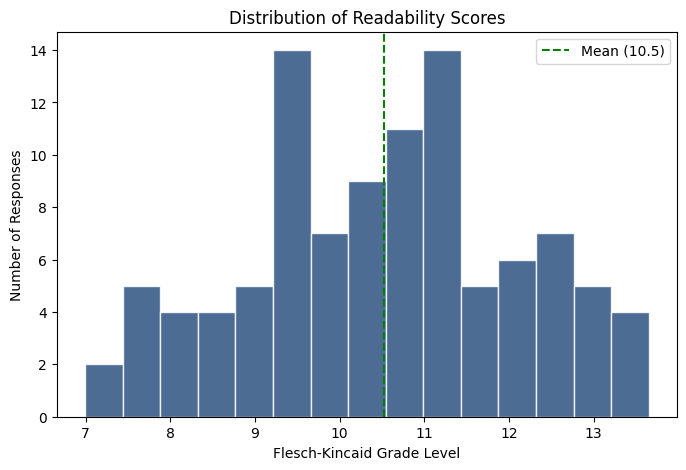

In [62]:
fk_scores = results_df['flesch_kincaid_grade'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(fk_scores, bins=15, color='#2c5282', edgecolor='white', alpha=0.85)
# plt.axvline(x=8, color='red', linestyle='--', label='Target (Grade 8)')
plt.axvline(x=fk_scores.mean(), color='green', linestyle='--', label=f'Mean ({fk_scores.mean():.1f})')
plt.xlabel('Flesch-Kincaid Grade Level')
plt.ylabel('Number of Responses')
plt.title('Distribution of Readability Scores')
plt.legend()
plt.savefig('fk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

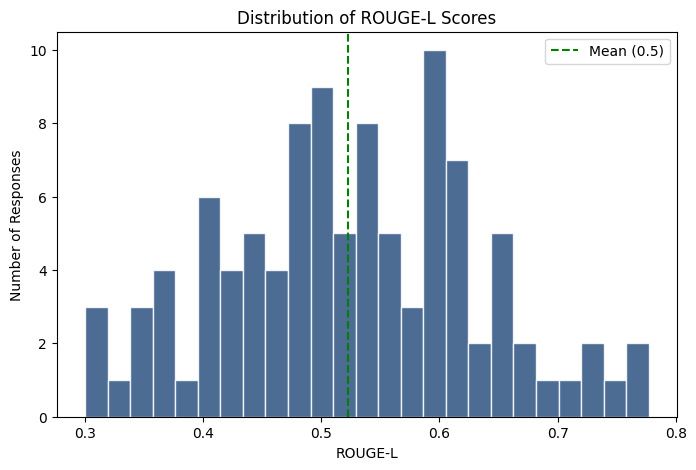

In [60]:
rl_scores = results_df['rouge_l_score'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(rl_scores, bins=25, color='#2c5282', edgecolor='white', alpha=0.85)
plt.axvline(x=rl_scores.mean(), color='green', linestyle='--', label=f'Mean ({rl_scores.mean():.1f})')
plt.xlabel('ROUGE-L')
plt.ylabel('Number of Responses')
plt.title('Distribution of ROUGE-L Scores')
plt.legend()
plt.savefig('rl_scores.png', dpi=150, bbox_inches='tight')
plt.show()

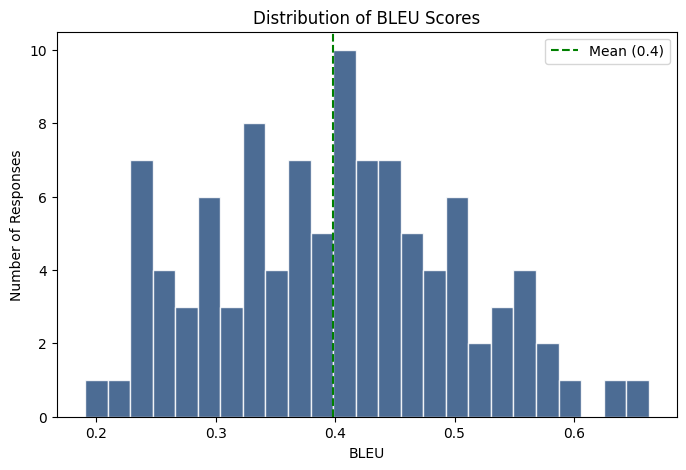

In [83]:
bl_scores = results_df['bleu_score'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(bl_scores, bins=25, color='#2c5282', edgecolor='white', alpha=0.85)
plt.axvline(x=bl_scores.mean(), color='green', linestyle='--', label=f'Mean ({bl_scores.mean():.1f})')
plt.xlabel('BLEU')
plt.ylabel('Number of Responses')
plt.title('Distribution of BLEU Scores')
plt.legend()
plt.savefig('bl_scores.png', dpi=150, bbox_inches='tight')
plt.show()

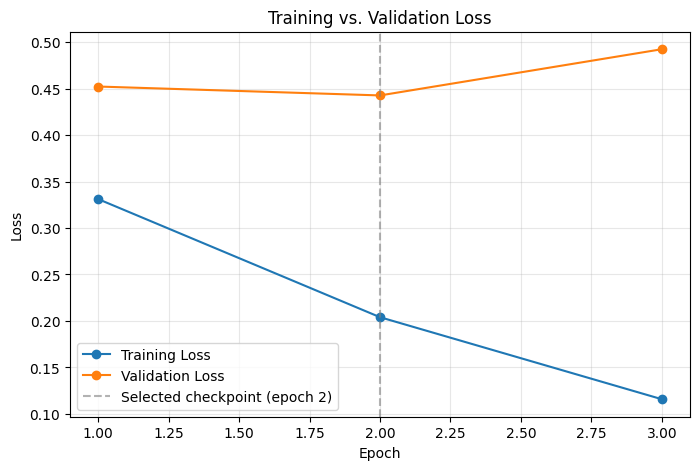

In [63]:
epochs = [1, 2, 3]
train_loss = [0.331095, 0.204027, 0.115776]
val_loss = [0.452242, 0.442667, 0.492387]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.axvline(x=2, color='gray', linestyle='--', alpha=0.6, label='Selected checkpoint (epoch 2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Testing Chat functionality

In [84]:
conversation_history = []

def chat(prompt: str, max_new_tokens: int = 1024, reset: bool = False) -> str:
    global conversation_history

    if reset:
        conversation_history = []

    conversation_history.append({"role": "user", "content": prompt})

    inputs = tokenizer.apply_chat_template(
        conversation_history, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    ).to(final_model.device)
    input_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        output = final_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        output = output[:, input_len:]

    response = tokenizer.decode(output[0], skip_special_tokens=True).strip()
    conversation_history.append({"role": "assistant", "content": response})

    return response

# --- Example usage: lab report explanation
lab_report_prompt = """[{"test": "Creatinine", "value": 3.7, "unit": "mg/dL", "test_name": "Creatinine", "status": "HIGH"}]"""

display(Markdown(f"**ANSWER:**\n\n{chat(lab_report_prompt, reset=True)}"))

**ANSWER:**

- **Creatinine (3.7, high):** Creatinine is a waste product filtered by the kidneys. A high level suggests that the kidneys may not be clearing waste as efficiently as they should, which can be a sign of reduced kidney function.

**Recommendation:** Talk with your doctor about the elevated creatinine. They may order additional kidney tests (such as eGFR or urine studies), review any medications, and discuss lifestyle steps (like staying well‑hydrated and controlling blood pressure or blood sugar) to protect your kidneys.

In [27]:
while True:
    follow_up = __builtins__.input("You: ")
    if follow_up.strip().lower() == "exit":
        break
    display(Markdown(f"**QUESTION:**\n\n{follow_up}"))
    display(Markdown(f"**ANSWER:**\n\n{chat(follow_up)}"))

You: Should I be worried?


**QUESTION:**

Should I be worried?

**ANSWER:**

- **Yes, be concerned.** A high creatinine often points to reduced kidney function and can be a cause for worry. It may indicate that the kidneys are not filtering waste as efficiently as they should, which can lead to other health issues if not addressed.

**Recommendation:** Discuss the elevated creatinine with your doctor. They may order additional kidney tests, review any medications, and suggest lifestyle steps (like staying well‑hydrated and controlling blood pressure or blood sugar) to protect your kidneys.

You: What does 'filtered by the kidneys' actually mean?


**QUESTION:**

What does 'filtered by the kidneys' actually mean?

...

**ANSWER:**

- **No, do not stop taking blood pressure medication.** High blood pressure is a common issue that can affect kidney function. Controlling blood pressure is an important step in protecting your kidneys. Continue taking your blood pressure medication as prescribed, and follow any additional guidance from your doctor.

**Recommendation:** Keep taking your blood pressure medication, and discuss any new symptoms or concerns with your healthcare provider. They may order additional kidney tests, review any medications, and suggest lifestyle steps (like staying well‑hydrated and controlling blood pressure or blood sugar) to protect your kidneys.

You: Can you just tell me if I have kidney disease or not?


**QUESTION:**

Can you just tell me if I have kidney disease or not?

**ANSWER:**

- **No, I cannot tell you if you have kidney disease.** Kidney disease is a complex issue that requires a thorough evaluation by a healthcare professional. Based on the elevated creatinine, it’s possible that you may have reduced kidney function, but further tests and a review of your overall health are needed to make a diagnosis.

**Recommendation:** Talk with your doctor about the elevated creatinine. They may order additional kidney tests, review any medications, and discuss lifestyle steps (like staying well‑hydrated and controlling blood pressure or blood sugar) to protect your kidneys.

You: exit
